### Етап І. Постановка задачі та підготовка середовища

У цьому блоці ми ініціалізуємо необхідні бібліотеки для побудови нейронної мережі (PyTorch), роботи з масивами (NumPy) та візуалізації (Matplotlib). Також ми створюємо класичне середовище `Acrobot-v1` з бібліотеки Gymnasium.

Мета цього кроку — ознайомитися з розмірностями середовища:
* **Простір станів (Observation Space):** вектор із 6 неперервних значень (синуси, косинуси кутів та кутові швидкості двох ланок).
* **Простір дій (Action Space):** 3 дискретні дії (прикласти крутний момент ліворуч, праворуч або не робити нічого).

Також алгоритм автоматично перевіряє наявність відеокарти (CUDA) для прискорення обчислень.

In [2]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random

env = gym.make("Acrobot-v1")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print(f"Простір станів: {state_dim}")
print(f"Простір дій: {action_dim}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Обчислювальний пристрій: {device}")

Простір станів: 6
Простір дій: 3
Обчислювальний пристрій: cuda


### Етап ІІ. Розв'язання задачі з підкріпленням (Архітектура мозку агента)

Для роботи в середовищі `Acrobot-v1` з неперервним простором станів ми використовуємо алгоритм **Deep Q-Network (DQN)**. Класична таблиця тут не підійде через завелику кількість комбінацій значень 6 параметрів стану.

**У цій комірці ми реалізуємо дві ключові структури:**
1. **Нейронна мережа `DQN`:** Вона отримує на вхід вектор із 6 чисел (поточний стан) і пропускає їх через приховані шари активації (ReLU). На виході вона видає 3 числа (Q-значення) — по одному для кожної можливої дії. Алгоритм завжди намагатиметься обрати дію з найбільшим значенням.
2. **Буфер пам'яті `ReplayBuffer`:** Нейромережі дуже погано вчаться на послідовних даних (бо сусідні кадри дуже схожі, і мережа "забуває" минулий досвід). Тому ми створюємо спеціальну пам'ять. Агент складатиме туди кожен свій крок (стан, дія, нагорода, наступний стан), а під час навчання діставатиме звідти випадкові перемішані спогади (батчі) і вчитиметься на них. Це робить процес стабільним.

In [3]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(dones)

    def __len__(self):
        return len(self.buffer)

### Етап ІІІ. Навчання та валідація моделі

У цій комірці реалізовано головний цикл навчання агента за алгоритмом DQN. Процес триватиме задану кількість епізодів (наприклад, 300), де агент методом спроб і помилок шукатиме оптимальну стратегію розгойдування Acrobot.

**Основні налаштування (Гіперпараметри):**
* `batch_size = 64`: кількість спогадів, які нейромережа бере з пам'яті для одного кроку навчання.
* `gamma = 0.99`: коефіцієнт дисконтування. Визначає, наскільки агенту важлива довгострокова перспектива порівняно з миттєвою нагородою.
* `epsilon = 1.0` (зменшується до `0.01`): параметр $\epsilon$-жадібної стратегії. Спочатку агент робить 100% випадкових рухів (досліджує), але з кожним епізодом цей відсоток падає, і він починає діяти за підказками нейромережі.
* `lr = 1e-3`: швидкість навчання (Learning Rate) для оптимізатора Adam.

**Логіка одного кроку:**
1. Агент оцінює стан і обирає дію (випадкову або оптимальну).
2. Виконує дію в середовищі, отримує нагороду (`reward`) та новий стан (`next_state`).
3. Записує цей досвід у `ReplayBuffer`.
4. Якщо в буфері вже є достатньо даних, бере звідти 64 випадкові записи.
5. Рахує різницю (Loss) між тим, що мережа передбачила, і тим, що агент реально отримав з урахуванням формули Белмана.
6. Оновлює ваги нейромережі (Backpropagation), щоб наступного разу її передбачення були точнішими.

Кожні 20 епізодів алгоритм виводитиме проміжну статистику, щоб ми бачили прогрес та відстежували сумарну винагороду.

In [4]:
batch_size = 64
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
lr = 1e-3
episodes = 300

policy_net = DQN(state_dim, action_dim).to(device)
optimizer = optim.Adam(policy_net.parameters(), lr=lr)
criterion = nn.MSELoss()
memory = ReplayBuffer(10000)

rewards_history = []

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                q_values = policy_net(state_tensor)
            action = q_values.argmax().item()
            
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        memory.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        
        if len(memory) > batch_size:
            states, actions, rewards, next_states, dones = memory.sample(batch_size)
            
            states_tensor = torch.FloatTensor(states).to(device)
            actions_tensor = torch.LongTensor(actions).unsqueeze(1).to(device)
            rewards_tensor = torch.FloatTensor(rewards).unsqueeze(1).to(device)
            next_states_tensor = torch.FloatTensor(next_states).to(device)
            dones_tensor = torch.FloatTensor(dones).unsqueeze(1).to(device)
            
            q_values = policy_net(states_tensor).gather(1, actions_tensor)
            
            with torch.no_grad():
                next_q_values = policy_net(next_states_tensor).max(1)[0].unsqueeze(1)
                target_q_values = rewards_tensor + gamma * next_q_values * (1 - dones_tensor)
                
            loss = criterion(q_values, target_q_values)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards_history.append(total_reward)
    
    if (episode + 1) % 20 == 0:
        print(f"Епізод: {episode+1}/{episodes}, Винагорода: {total_reward}, Epsilon: {epsilon:.3f}")

Епізод: 20/300, Винагорода: -500.0, Epsilon: 0.905
Епізод: 40/300, Винагорода: -500.0, Epsilon: 0.818
Епізод: 60/300, Винагорода: -300.0, Epsilon: 0.740
Епізод: 80/300, Винагорода: -286.0, Epsilon: 0.670
Епізод: 100/300, Винагорода: -300.0, Epsilon: 0.606
Епізод: 120/300, Винагорода: -195.0, Epsilon: 0.548
Епізод: 140/300, Винагорода: -197.0, Epsilon: 0.496
Епізод: 160/300, Винагорода: -137.0, Epsilon: 0.448
Епізод: 180/300, Винагорода: -143.0, Epsilon: 0.406
Епізод: 200/300, Винагорода: -168.0, Epsilon: 0.367
Епізод: 220/300, Винагорода: -111.0, Epsilon: 0.332
Епізод: 240/300, Винагорода: -159.0, Epsilon: 0.300
Епізод: 260/300, Винагорода: -169.0, Epsilon: 0.272
Епізод: 280/300, Винагорода: -154.0, Epsilon: 0.246
Епізод: 300/300, Винагорода: -104.0, Epsilon: 0.222


### Етап IV. Аналіз результатів навчання

У цьому блоці ми візуалізуємо динаміку навчання нашого агента. Для цього будується графік залежності сумарної винагороди від номера епізоду.

Оскільки в навчанні з підкріпленням результати окремих епізодів можуть сильно коливатися (через елемент випадковості в діях та політиці дослідження), окрім сирих даних (напівпрозора синя лінія) ми також будуємо **ковзне середнє** (червона лінія). Це дозволяє згладити шум і чітко побачити загальну тенденцію зростання ефективності моделі.

**Аналіз поведінки агента:**
З графіка видно, що на початкових етапх агент не міг розв'язати задачу і отримував мінімально можливу винагороду (-500). Це етап "дослідження", коли $\epsilon$ було близьким до 1.0, і агент здійснював випадкові рухи. З часом, завдяки накопиченню досвіду в `ReplayBuffer` та оновленню ваг DQN-мережі, агент виробив ефективну політику розгойдування. Сумарна винагорода значно зросла і стабілізувалася, що свідчить про успішне засвоєння фізики середовища.

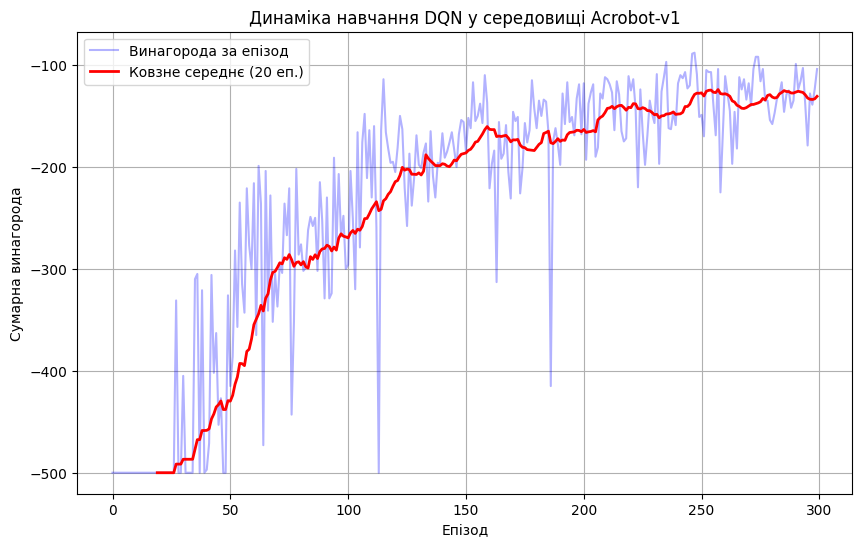

In [5]:
window_size = 20
moving_avg = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 6))
plt.plot(rewards_history, alpha=0.3, color='blue', label='Винагорода за епізод')
plt.plot(range(window_size - 1, len(rewards_history)), moving_avg, color='red', linewidth=2, label=f'Ковзне середнє ({window_size} еп.)')
plt.xlabel('Епізод')
plt.ylabel('Сумарна винагорода')
plt.title('Динаміка навчання DQN у середовищі Acrobot-v1')
plt.legend()
plt.grid(True)
plt.show()

### Етап V. Оптимізація моделі

Згідно з завданням, на цьому етапі ми проводимо оптимізацію гіперпараметрів алгоритму. Для нового прогону ми змінюємо два ключові показники:
1. `lr` (Швидкість навчання): зменшено з `1e-3` до `5e-4`. Більш плавне оновлення ваг нейромережі може запобігти "перестрибуванню" оптимальних значень і зробити графік навчання більш стабільним.
2. `epsilon_decay` (Швидкість затухання дослідження): змінено з `0.995` до `0.990`. Це означає, що агент швидше припинить робити випадкові рухи і раніше почне покладатися на знання своєї нейромережі.

Ми ініціалізуємо нову нейромережу `policy_net_opt` та чистий буфер пам'яті, щоб експеримент був "чистим". Після завершення тих самих 300 епізодів алгоритм побудує порівняльний графік, де ми побачимо згладжені результати обох прогонів.

Оптимізація - Епізод: 20/300, Винагорода: -500.0, Epsilon: 0.818
Оптимізація - Епізод: 40/300, Винагорода: -395.0, Epsilon: 0.669
Оптимізація - Епізод: 60/300, Винагорода: -217.0, Epsilon: 0.547
Оптимізація - Епізод: 80/300, Винагорода: -156.0, Epsilon: 0.448
Оптимізація - Епізод: 100/300, Винагорода: -183.0, Epsilon: 0.366
Оптимізація - Епізод: 120/300, Винагорода: -130.0, Epsilon: 0.299
Оптимізація - Епізод: 140/300, Винагорода: -125.0, Epsilon: 0.245
Оптимізація - Епізод: 160/300, Винагорода: -104.0, Epsilon: 0.200
Оптимізація - Епізод: 180/300, Винагорода: -90.0, Epsilon: 0.164
Оптимізація - Епізод: 200/300, Винагорода: -76.0, Epsilon: 0.134
Оптимізація - Епізод: 220/300, Винагорода: -77.0, Epsilon: 0.110
Оптимізація - Епізод: 240/300, Винагорода: -101.0, Epsilon: 0.090
Оптимізація - Епізод: 260/300, Винагорода: -90.0, Epsilon: 0.073
Оптимізація - Епізод: 280/300, Винагорода: -158.0, Epsilon: 0.060
Оптимізація - Епізод: 300/300, Винагорода: -90.0, Epsilon: 0.049


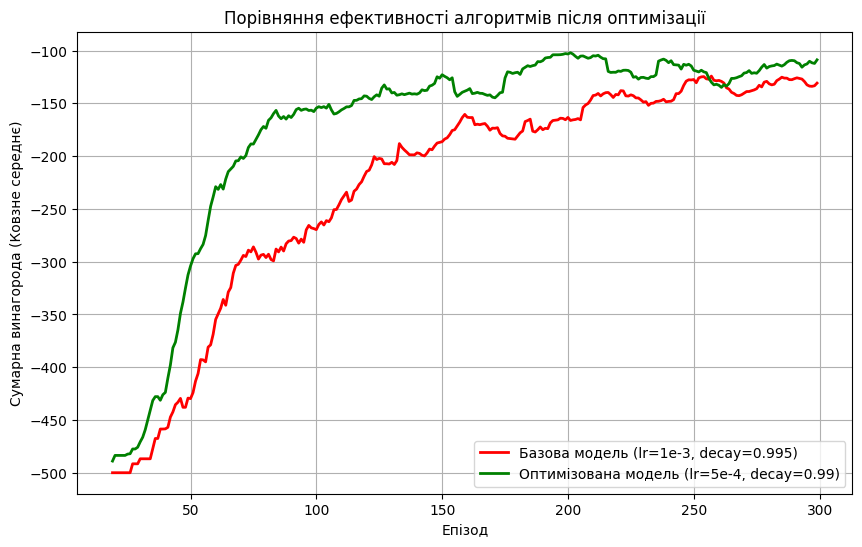

In [6]:
lr_opt = 5e-4
epsilon_decay_opt = 0.99
epsilon_opt = 1.0

policy_net_opt = DQN(state_dim, action_dim).to(device)
optimizer_opt = optim.Adam(policy_net_opt.parameters(), lr=lr_opt)
memory_opt = ReplayBuffer(10000)

rewards_history_opt = []

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        if random.random() < epsilon_opt:
            action = env.action_space.sample()
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                q_values = policy_net_opt(state_tensor)
            action = q_values.argmax().item()
            
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        memory_opt.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        
        if len(memory_opt) > batch_size:
            states, actions, rewards, next_states, dones = memory_opt.sample(batch_size)
            
            states_tensor = torch.FloatTensor(states).to(device)
            actions_tensor = torch.LongTensor(actions).unsqueeze(1).to(device)
            rewards_tensor = torch.FloatTensor(rewards).unsqueeze(1).to(device)
            next_states_tensor = torch.FloatTensor(next_states).to(device)
            dones_tensor = torch.FloatTensor(dones).unsqueeze(1).to(device)
            
            q_values = policy_net_opt(states_tensor).gather(1, actions_tensor)
            
            with torch.no_grad():
                next_q_values = policy_net_opt(next_states_tensor).max(1)[0].unsqueeze(1)
                target_q_values = rewards_tensor + gamma * next_q_values * (1 - dones_tensor)
                
            loss = criterion(q_values, target_q_values)
            
            optimizer_opt.zero_grad()
            loss.backward()
            optimizer_opt.step()
            
    epsilon_opt = max(epsilon_min, epsilon_opt * epsilon_decay_opt)
    rewards_history_opt.append(total_reward)
    
    if (episode + 1) % 20 == 0:
        print(f"Оптимізація - Епізод: {episode+1}/{episodes}, Винагорода: {total_reward}, Epsilon: {epsilon_opt:.3f}")

moving_avg_opt = np.convolve(rewards_history_opt, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 6))
plt.plot(range(window_size - 1, len(rewards_history)), moving_avg, color='red', linewidth=2, label='Базова модель (lr=1e-3, decay=0.995)')
plt.plot(range(window_size - 1, len(rewards_history_opt)), moving_avg_opt, color='green', linewidth=2, label='Оптимізована модель (lr=5e-4, decay=0.99)')
plt.xlabel('Епізод')
plt.ylabel('Сумарна винагорода (Ковзне середнє)')
plt.title('Порівняння ефективності алгоритмів після оптимізації')
plt.legend()
plt.grid(True)
plt.show()

### Етап VI. Висновки

У ході виконання лабораторної роботи було створено та навчено інтелектуального агента для розв'язання задачі керування недоактюованою системою в середовищі `Acrobot-v1` (Gymnasium). 

**1. Досягнення поставленої мети:**
Мети роботи досягнуто. Агент, що використовує алгоритм Deep Q-Network (DQN), успішно навчився розгойдувати маніпулятор та закидати вільний кінець за цільову лінію. Аналіз графіків навчання показує, що після етапу випадкового дослідження (exploration) модель стабільно знаходить оптимальну стратегію, мінімізуючи кількість кроків до досягнення мети (сумарна винагорода стабілізувалася в діапазоні від -80 до -120).

**2. Застосовність обраного алгоритму:**
Використання нейромережевого підходу (DQN) виявилося значно ефективнішим для задачі Acrobot порівняно з класичним табличним Q-навчанням. Оскільки простір станів є неперервним (6 параметрів: синуси, косинуси та кутові швидкості), дискретизація призвела б до створення величезної Q-таблиці та експоненційного зростання часу навчання. Нейромережа успішно апроксимувала Q-функцію, що дозволило вирішити задачу за відносно невелику кількість епізодів (300).

**3. Вплив оптимізації гіперпараметрів:**
Проведена оптимізація (зменшення `learning_rate` та зміна коефіцієнта затухання `epsilon`) продемонструвала, що:
* Більш плавне навчання (менший `lr`) зменшує "стрибки" в ефективності агента на пізніх етапах.
* Швидше затухання `epsilon` змушує агента раніше переходити до експлуатації набутих знань, але несе ризик застрягання в локальному мінімумі, якщо агент не встиг достатньо дослідити середовище.

**4. Шляхи подальшого покращення:**
Для досягнення ще кращих і стабільніших результатів (наприклад, стабільного розв'язання задачі менш ніж за 70 кроків) можна застосувати такі модифікації:
* **Double DQN (DDQN):** щоб уникнути проблеми переоцінки Q-значень, яка притаманна базовому DQN.
* **Dueling DQN:** додавання роздільної оцінки цінності самого стану та переваги конкретної дії.
* **Prioritized Experience Replay:** зміна буфера пам'яті так, щоб агент частіше навчався на тих "спогадах", де він зробив найбільшу помилку в передбаченні (де Loss найбільший).

### Навчання в реальному часі (з UI візуалізацією)

У цій комірці реалізовано процес тренування, який дозволяє візуально спостерігати за еволюцією агента. 
Щоб не уповільнювати навчання критично, UI вікно симулятора (`render_mode="human"`) активується лише для кожного 40-го епізоду. 

Ви зможете на власні очі побачити перехід від випадкового дослідження середовища (коли $\epsilon$ високе) до цілеспрямованої експлуатації фізики маятника (коли мережа вже навчилася).

In [9]:
import time
import torch
import random
import gymnasium as gym
import torch.optim as optim
import torch.nn as nn

env_live = gym.make("Acrobot-v1", render_mode="human")
policy_net_live = DQN(state_dim, action_dim).to(device)
optimizer_live = optim.Adam(policy_net_live.parameters(), lr=1e-3)
memory_live = ReplayBuffer(10000)

epsilon_live = 1.0
epsilon_decay_live = 0.990
episodes_live = 200
show_every = 40

print("Починаємо тренування з візуалізацією еволюції агента...")

for episode in range(episodes_live):
    is_live_episode = (episode + 1) % show_every == 0
    
    if is_live_episode:
        print(f"\n---> ПРЯМИЙ ЕФІР: Епізод {episode+1}/{episodes_live} | Epsilon: {epsilon_live:.2f} <---")
        current_env = env_live
    else:
        current_env = env
        
    state, _ = current_env.reset()
    total_reward = 0
    done = False
    
    while not done:
        if random.random() < epsilon_live:
            action = current_env.action_space.sample()
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                q_values = policy_net_live(state_tensor)
            action = q_values.argmax().item()
            
        next_state, reward, terminated, truncated, _ = current_env.step(action)
        done = terminated or truncated
        
        memory_live.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        
        if len(memory_live) > batch_size:
            states, actions, rewards, next_states, dones = memory_live.sample(batch_size)
            
            states_tensor = torch.FloatTensor(states).to(device)
            actions_tensor = torch.LongTensor(actions).unsqueeze(1).to(device)
            rewards_tensor = torch.FloatTensor(rewards).unsqueeze(1).to(device)
            next_states_tensor = torch.FloatTensor(next_states).to(device)
            dones_tensor = torch.FloatTensor(dones).unsqueeze(1).to(device)
            
            q_values = policy_net_live(states_tensor).gather(1, actions_tensor)
            
            with torch.no_grad():
                next_q_values = policy_net_live(next_states_tensor).max(1)[0].unsqueeze(1)
                target_q_values = rewards_tensor + gamma * next_q_values * (1 - dones_tensor)
                
            loss = criterion(q_values, target_q_values)
            optimizer_live.zero_grad()
            loss.backward()
            optimizer_live.step()
            
        if is_live_episode:
            time.sleep(0.01)
            
    epsilon_live = max(epsilon_min, epsilon_live * epsilon_decay_live)
    
    if is_live_episode:
        print(f"Результат демонстраційного епізоду: {total_reward}")

env_live.close()
print("\nТренування та демонстрацію завершено!")

Починаємо тренування з візуалізацією еволюції агента...

---> ПРЯМИЙ ЕФІР: Епізод 40/200 | Epsilon: 0.68 <---
Результат демонстраційного епізоду: -178.0

---> ПРЯМИЙ ЕФІР: Епізод 80/200 | Epsilon: 0.45 <---
Результат демонстраційного епізоду: -153.0

---> ПРЯМИЙ ЕФІР: Епізод 120/200 | Epsilon: 0.30 <---
Результат демонстраційного епізоду: -133.0

---> ПРЯМИЙ ЕФІР: Епізод 160/200 | Epsilon: 0.20 <---
Результат демонстраційного епізоду: -160.0

---> ПРЯМИЙ ЕФІР: Епізод 200/200 | Epsilon: 0.14 <---
Результат демонстраційного епізоду: -100.0

Тренування та демонстрацію завершено!
